# 01 数据准备 & 模型缓存

本 notebook 完成以下工作:
1. 安装项目依赖
2. 下载猫咪图片数据集 (Oxford-IIIT Pet + COCO cat subset)
3. 预下载所有模型到本地缓存
4. 策划 50 张评估集
5. 生成标注模板

**运行环境**: RTX 5080 (16GB VRAM) / CUDA

**预计耗时**: 首次运行约 30-60 分钟（取决于网络速度）

## 1. 安装依赖

In [1]:
# 安装项目所有依赖包
# 如果在 WSL conda 环境中已经安装过，可以跳过此步骤
# !pip install -r ../requirements.txt -q
print("跳过安装 — 依赖已在 conda 环境中安装完毕")

跳过安装 — 依赖已在 conda 环境中安装完毕


In [2]:
# 验证关键依赖是否安装成功
import torch
import torchvision
import transformers
import ultralytics

print(f"PyTorch: {torch.__version__}")
print(f"TorchVision: {torchvision.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"Ultralytics: {ultralytics.__version__}")
print(f"CUDA 可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    print(f"显存: {props.total_memory / 1024**3:.1f} GB")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/atlas/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch: 2.11.0+cu128
TorchVision: 0.26.0+cu128
Transformers: 5.5.0
Ultralytics: 8.4.34
CUDA 可用: True
GPU: NVIDIA GeForce RTX 5080
显存: 15.9 GB


## 2. 下载猫咪图片数据集

### 2.1 Oxford-IIIT Pet Dataset

包含约 7,349 张宠物图片（其中约 2,400 张猫），12 个猫品种。
带有分割 mask 和品种标签。

In [3]:
import os
from pathlib import Path

# 设置数据目录
DATA_DIR = Path("../data")
CAT_IMAGES_DIR = DATA_DIR / "cat_images"
EVAL_SET_DIR = DATA_DIR / "eval_set"

# 创建必要的目录
CAT_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
EVAL_SET_DIR.mkdir(parents=True, exist_ok=True)

print(f"数据目录: {DATA_DIR.resolve()}")
print(f"猫咪图片目录: {CAT_IMAGES_DIR.resolve()}")
print(f"评估集目录: {EVAL_SET_DIR.resolve()}")

数据目录: /home/atlas/hajimi/data
猫咪图片目录: /home/atlas/hajimi/data/cat_images
评估集目录: /home/atlas/hajimi/data/eval_set


In [4]:
from torchvision.datasets import OxfordIIITPet
from PIL import Image
import shutil

# Download Oxford-IIIT Pet dataset (~800MB first time)
# If already downloaded, this will skip the download automatically
download_needed = not (DATA_DIR / "oxford_pet" / "oxford-iiit-pet").exists()
print(f"Downloading Oxford-IIIT Pet dataset..." if download_needed else "Oxford-IIIT Pet already downloaded, loading from cache...")

pet_dataset = OxfordIIITPet(
    root=str(DATA_DIR / "oxford_pet"),
    split="trainval",
    download=download_needed,
)

print(f"Dataset size: {len(pet_dataset)} images")

Oxford-IIIT Pet already downloaded, loading from cache...
Dataset size: 3680 images


In [5]:
# Oxford-IIIT Pet cat breeds (9 breeds, cats only)
# 注意: 数据集类名用空格，提取时转成下划线存文件名
CAT_BREED_NAMES = {
    "Abyssinian", "British Shorthair", "Egyptian Mau",
    "Maine Coon", "Persian", "Ragdoll",
    "Russian Blue", "Siamese", "Sphynx"
}

existing_cats = list(CAT_IMAGES_DIR.glob("oxford_*.jpg"))
if len(existing_cats) > 100:
    print(f"Cat images already extracted: {len(existing_cats)} files, skipping...")
else:
    class_names = pet_dataset.classes
    cat_count = 0
    for i in range(len(pet_dataset)):
        img, label = pet_dataset[i]
        breed_name = class_names[label]
        if breed_name not in CAT_BREED_NAMES:
            continue
        safe_name = breed_name.replace(' ', '_')
        dest = CAT_IMAGES_DIR / f"oxford_{safe_name}_{cat_count:04d}.jpg"
        if not dest.exists():
            img.save(dest)
        cat_count += 1
    print(f"Extracted {cat_count} cat images to {CAT_IMAGES_DIR}")

print(f"Cat breeds: {sorted(CAT_BREED_NAMES)}")


Cat images already extracted: 1189 files, skipping...
Cat breeds: ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx']


### 2.2 浏览数据集样本

随机展示一些猫咪图片，了解数据质量和多样性。

Total cat images: 1189


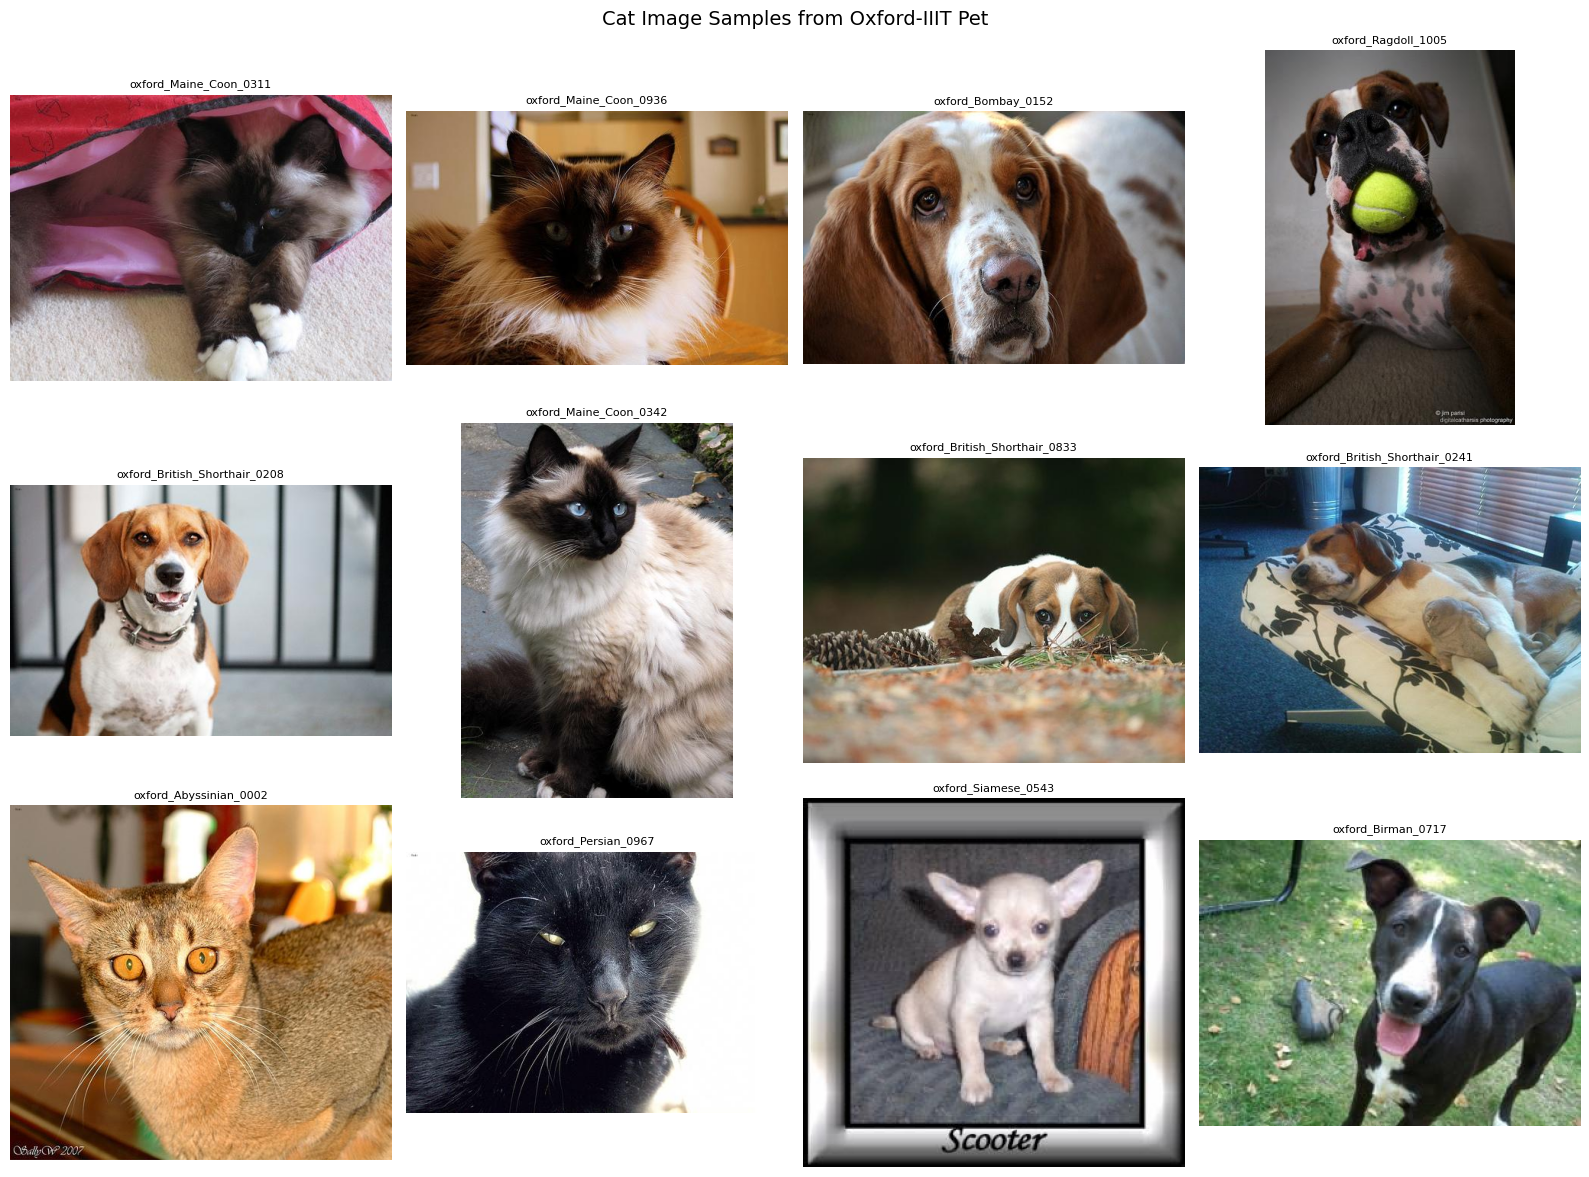

In [6]:
import random
import matplotlib.pyplot as plt

# Get all cat image paths
cat_images = sorted(CAT_IMAGES_DIR.glob("*.jpg"))
print(f"Total cat images: {len(cat_images)}")

# Show 12 random samples
sample_images = random.sample(cat_images, min(12, len(cat_images)))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, img_path in zip(axes.flat, sample_images):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(img_path.stem[:30], fontsize=8)
    ax.axis("off")

plt.suptitle("Cat Image Samples from Oxford-IIIT Pet", fontsize=14)
plt.tight_layout()
plt.show()

## 3. 预下载模型

将所有模型预下载到本地缓存，避免后续运行时等待下载。

| 模型 | 用途 | 大小 |
|------|------|------|
| YOLOv8n | 猫咪检测 | ~6MB |
| Qwen3-VL-2B-Instruct | 体态分析 | ~4GB |
| CLIP ViT-L/14 | 情绪分类 | ~1.5GB |
| Qwen3-8B | 内心独白 | ~5GB (4-bit) |

In [7]:
# 3.1 Download YOLOv8n model
print("=" * 50)
print("YOLOv8n Model")
print("=" * 50)

from ultralytics import YOLO

model = YOLO("yolov8n.pt")
print(f"YOLOv8n loaded! Classes: {len(model.names)}, cat ID: 15 -> {model.names[15]}")
del model

YOLOv8n Model
YOLOv8n loaded! Classes: 80, cat ID: 15 -> cat


In [8]:
# 3.2 Download CLIP ViT-L/14 model
print("=" * 50)
print("CLIP ViT-L/14 Model")
print("=" * 50)

import clip

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, clip_preprocess = clip.load("ViT-L/14", device=device)
print(f"CLIP ViT-L/14 loaded on {device}")

# Quick test
text = clip.tokenize(["a photo of a cat"]).to(device)
with torch.no_grad():
    text_features = clip_model.encode_text(text)
print(f"Text feature dim: {text_features.shape}")

del clip_model, clip_preprocess, text_features
torch.cuda.empty_cache()

CLIP ViT-L/14 Model
CLIP ViT-L/14 loaded on cuda
Text feature dim: torch.Size([1, 768])


In [9]:
# 3.3 Download Qwen3-VL-2B-Instruct (body language analysis)
print("=" * 50)
print("Qwen3-VL-2B-Instruct Model")
print("=" * 50)

from transformers import AutoProcessor, Qwen3VLForConditionalGeneration
import gc

VL_MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"

print("Loading processor...")
vl_processor = AutoProcessor.from_pretrained(VL_MODEL_ID)

print("Loading model weights (FP16)...")
vl_model = Qwen3VLForConditionalGeneration.from_pretrained(
    VL_MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)
print(f"Qwen3-VL-2B loaded! Params: {sum(p.numel() for p in vl_model.parameters()) / 1e9:.2f}B")

del vl_model, vl_processor
torch.cuda.empty_cache()
gc.collect()
print("Memory released.")

Qwen3-VL-2B-Instruct Model
Loading processor...


Loading model weights (FP16)...


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

Qwen3-VL-2B loaded! Params: 2.13B
Memory released.


In [10]:
# 3.4 Download Qwen3-8B (monologue generation, 4-bit quantized)
print("=" * 50)
print("Qwen3-8B Model (4-bit)")
print("=" * 50)

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

LLM_MODEL_ID = "Qwen/Qwen3-8B"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading tokenizer...")
llm_tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_ID)

print("Loading model weights (4-bit)...")
llm_model = AutoModelForCausalLM.from_pretrained(
    LLM_MODEL_ID,
    quantization_config=quantization_config,
    device_map="auto",
)
print(f"Qwen3-8B (4-bit) loaded!")

if torch.cuda.is_available():
    mem_used = torch.cuda.memory_allocated() / 1024**3
    print(f"VRAM usage: {mem_used:.2f} GB")

del llm_model, llm_tokenizer
torch.cuda.empty_cache()
gc.collect()
print("Memory released.")

Qwen3-8B Model (4-bit)
Loading tokenizer...
Loading model weights (4-bit)...


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

/home/atlas/miniconda3/envs/hajimi/lib/python3.11/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Qwen3-8B (4-bit) loaded!
VRAM usage: 5.70 GB
Memory released.


In [11]:
# 3.5 Verify model cache
print("=" * 50)
print("Model Cache Status")
print("=" * 50)

from huggingface_hub import scan_cache_dir

cache_info = scan_cache_dir()

print("\nCached models:")
for repo in cache_info.repos:
    if any(m in repo.repo_id for m in ["Qwen3", "clip"]):
        size_gb = repo.size_on_disk / 1024**3
        print(f"  {repo.repo_id} ({size_gb:.2f} GB)")

print("\nAll models cached locally!")

Model Cache Status

Cached models:
  Qwen/Qwen3-VL-2B-Instruct (3.97 GB)
  Qwen/Qwen3-8B (15.27 GB)

All models cached locally!


## 4. 策划评估集

从已下载的猫咪图片中，手动挑选 50 张用于 CLIP 消融实验评估。

选择标准:
- 覆盖 6 种情绪类别
- 每张图片只有一只清晰可见的猫
- 姿态多样（站、坐、躺、跑等）

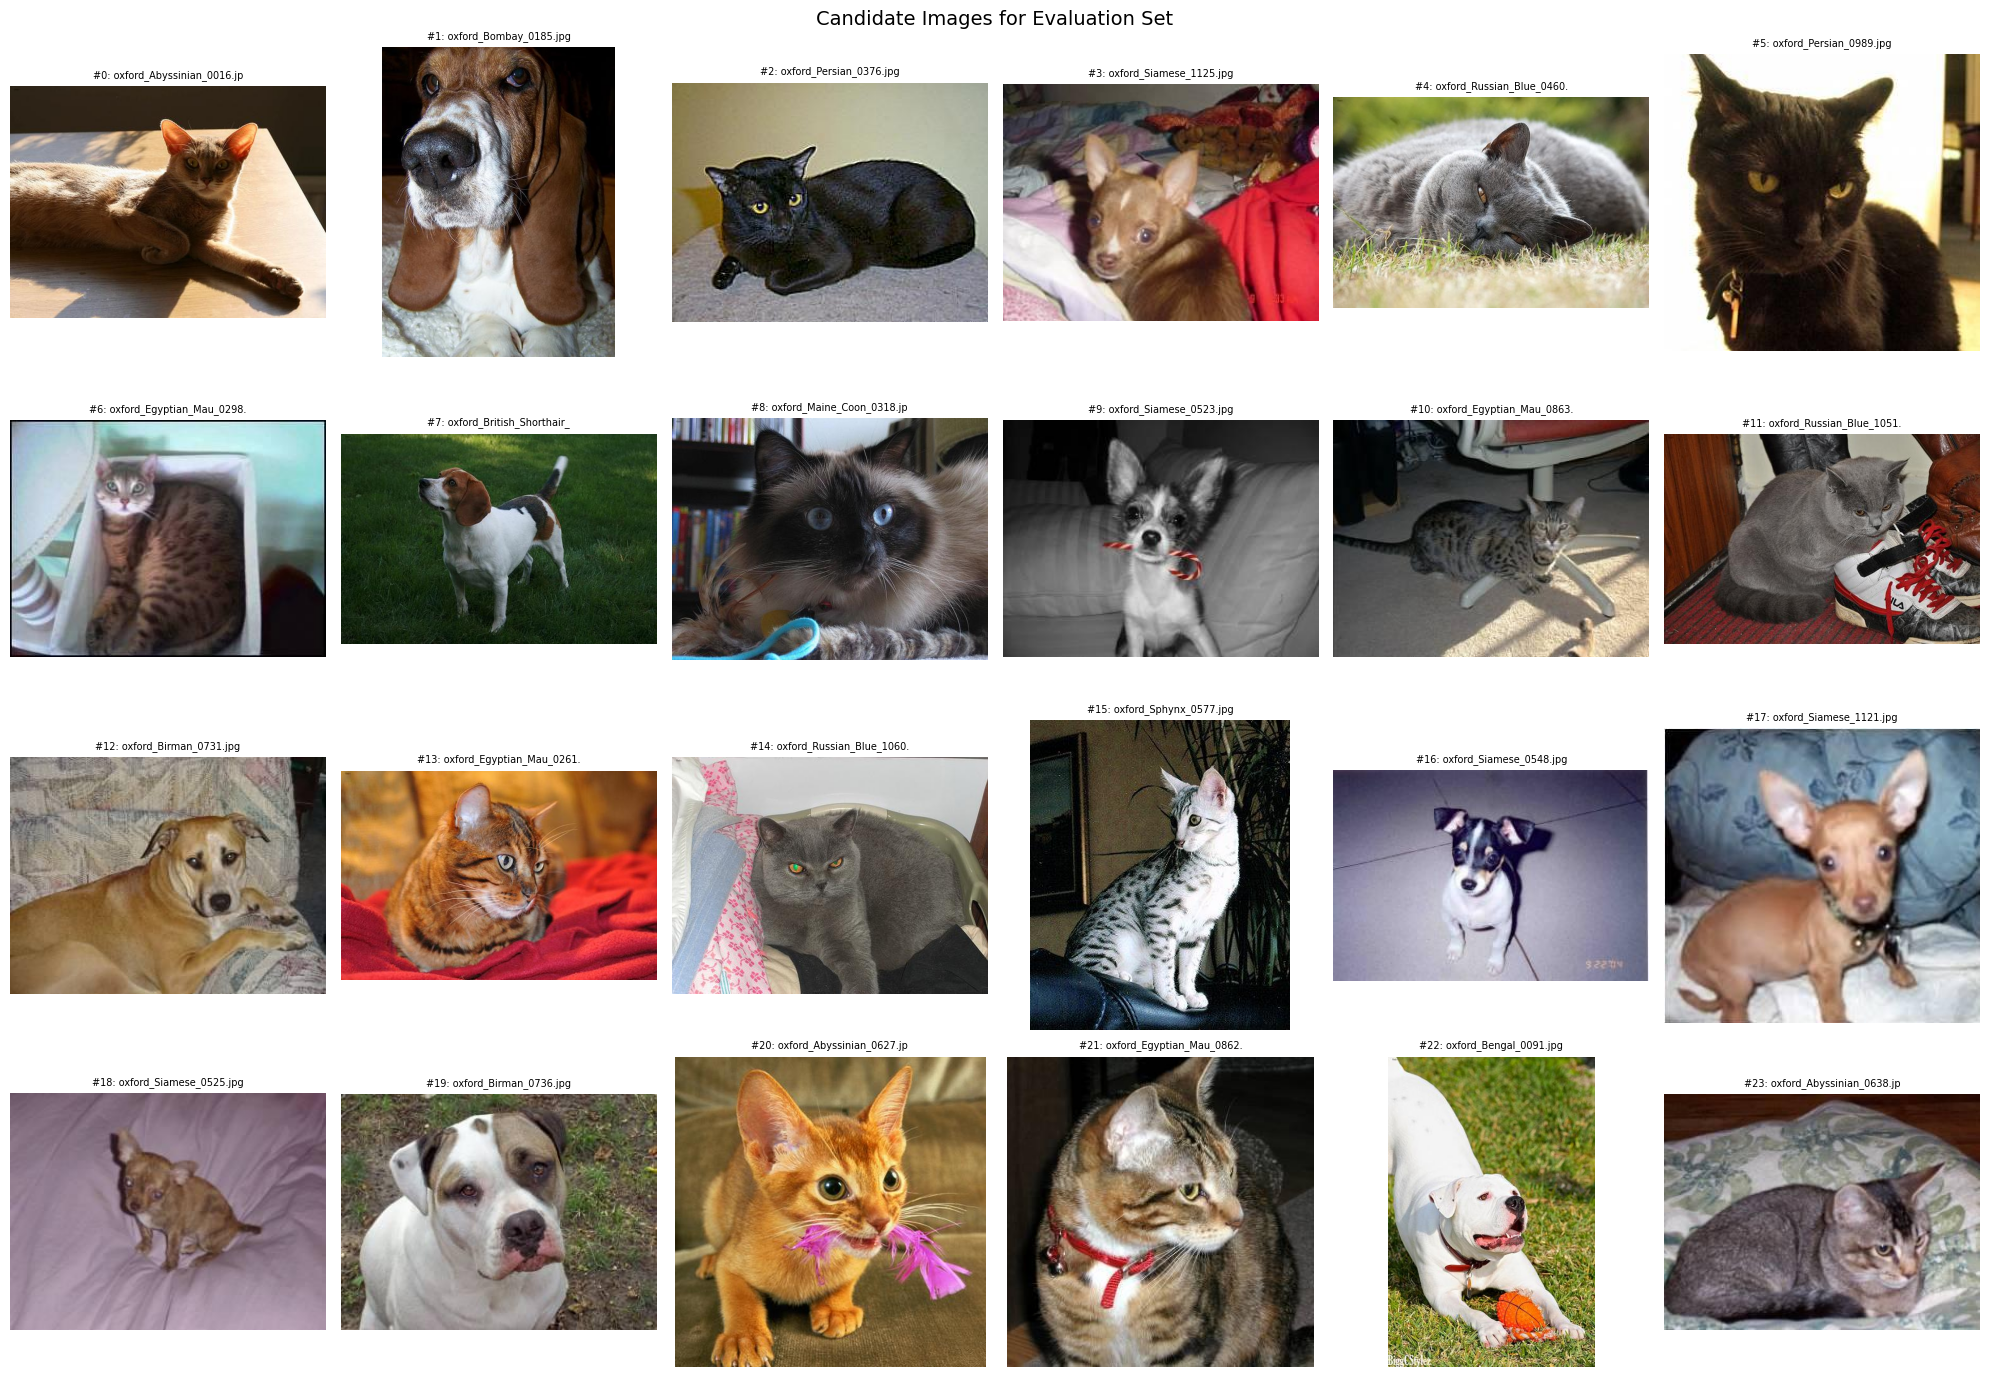


Tip: Run this cell multiple times to see different samples
Then add selected filenames to the next cell


In [12]:
# Browse candidate images for evaluation set selection
# Run this cell multiple times to see different random samples

cat_images = sorted(CAT_IMAGES_DIR.glob("*.jpg"))
sample = random.sample(cat_images, min(24, len(cat_images)))

fig, axes = plt.subplots(4, 6, figsize=(20, 14))
for idx, (ax, img_path) in enumerate(zip(axes.flat, sample)):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"#{idx}: {img_path.name[:25]}", fontsize=7)
    ax.axis("off")

plt.suptitle("Candidate Images for Evaluation Set", fontsize=14)
plt.tight_layout()
plt.show()

print("\nTip: Run this cell multiple times to see different samples")
print("Then add selected filenames to the next cell")

In [13]:
# Select 50 evaluation images
# Add manually picked filenames to the list below, or leave empty for random selection

eval_image_names = [
    # Add selected filenames here:
    # "oxford_Abyssinian_0001.jpg",
    # "oxford_Bengal_0042.jpg",
]

# Skip if eval set already exists
existing_eval = list(EVAL_SET_DIR.glob("eval_*.jpg"))
if len(existing_eval) >= 50:
    print(f"Eval set already exists: {len(existing_eval)} images, skipping...")
else:
    if len(eval_image_names) == 0:
        print("No manual selection, randomly picking 50 images...")
        cat_images = sorted(CAT_IMAGES_DIR.glob("*.jpg"))
        eval_sample = random.sample(cat_images, min(50, len(cat_images)))
        eval_image_names = [p.name for p in eval_sample]
    
    for i, name in enumerate(eval_image_names):
        src = CAT_IMAGES_DIR / name
        if src.exists():
            dest = EVAL_SET_DIR / f"eval_{i+1:03d}.jpg"
            shutil.copy2(src, dest)

eval_count = len(list(EVAL_SET_DIR.glob("*.jpg")))
print(f"Eval set ready: {eval_count} images in {EVAL_SET_DIR}")

Eval set already exists: 50 images, skipping...
Eval set ready: 50 images in ../data/eval_set


## 5. 生成标注模板

为两位标注者生成 JSON 标注模板。
每位标注者需要为每张图片标注:
- 主要情绪 (6 选 1)
- 置信度 (1-5)
- 可选: 次要情绪

In [14]:
import json

EMOTIONS = ["relaxed", "curious", "fearful", "aggressive", "playful", "content"]

annotations_dir = Path("../eval/annotations")
annotations_dir.mkdir(parents=True, exist_ok=True)

# Skip if annotation templates already exist
ann1_path = annotations_dir / "annotator_1.json"
if ann1_path.exists():
    with open(ann1_path, "r", encoding="utf-8") as f:
        existing = json.load(f)
    print(f"Annotation templates already exist ({len(existing)} images), skipping...")
else:
    eval_images = sorted(EVAL_SET_DIR.glob("*.jpg"))
    annotation_template = {}
    for img_path in eval_images:
        annotation_template[img_path.name] = {
            "primary_emotion": "",
            "confidence": 0,
            "secondary_emotion": "",
            "notes": "",
        }
    
    for annotator_id in [1, 2]:
        template_path = annotations_dir / f"annotator_{annotator_id}.json"
        with open(template_path, "w", encoding="utf-8") as f:
            json.dump(annotation_template, f, indent=2, ensure_ascii=False)
        print(f"Template saved: {template_path}")
    
    print(f"\nEmotions: {EMOTIONS}")
    print(f"Images to annotate: {len(annotation_template)}")
    print("Each annotator should fill in their own JSON file")

Annotation templates already exist (50 images), skipping...


## 6. 快速验证 Pipeline

用一张图片快速测试各模块是否能正常工作。

Test image: oxford_Abyssinian_0000.jpg
Image size: (394, 500)


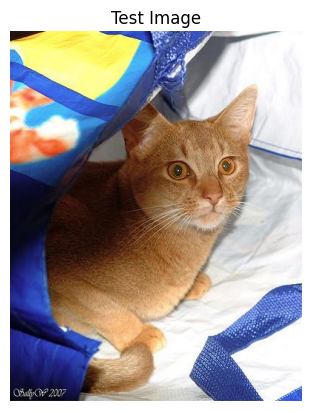

In [15]:
# Quick pipeline test with one image
import sys
sys.path.insert(0, "..")

test_images = sorted(CAT_IMAGES_DIR.glob("*.jpg"))
if test_images:
    test_img = Image.open(test_images[0])
    print(f"Test image: {test_images[0].name}")
    print(f"Image size: {test_img.size}")
    plt.imshow(test_img)
    plt.axis("off")
    plt.title("Test Image")
    plt.show()
else:
    print("WARNING: No cat images found. Run data download steps first.")

Testing YOLO detection...
Detected 1 cat(s)
  Cat #1: conf=84.20%, bbox=[40, 73, 339, 478]


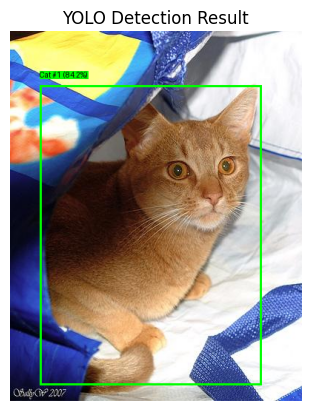

In [16]:
# Test Module A: YOLO cat detection
from src.detector import CatDetector

print("Testing YOLO detection...")
detector = CatDetector()
detections = detector.detect(test_img)

print(f"Detected {len(detections)} cat(s)")
for i, det in enumerate(detections):
    print(f"  Cat #{i+1}: conf={det['confidence']:.2%}, bbox={det['bbox']}")

# Show detection result
from src.utils import draw_bboxes
if detections:
    result_img = draw_bboxes(test_img, detections)
    plt.imshow(result_img)
    plt.axis("off")
    plt.title("YOLO Detection Result")
    plt.show()

Testing CLIP emotion classification...

Emotion distribution:
  playful     : 62.7% █████████████████████████
  fearful     : 33.1% █████████████
  curious     : 2.9% █
  relaxed     : 1.0% 
  aggressive  : 0.2% 
  content     : 0.1% 


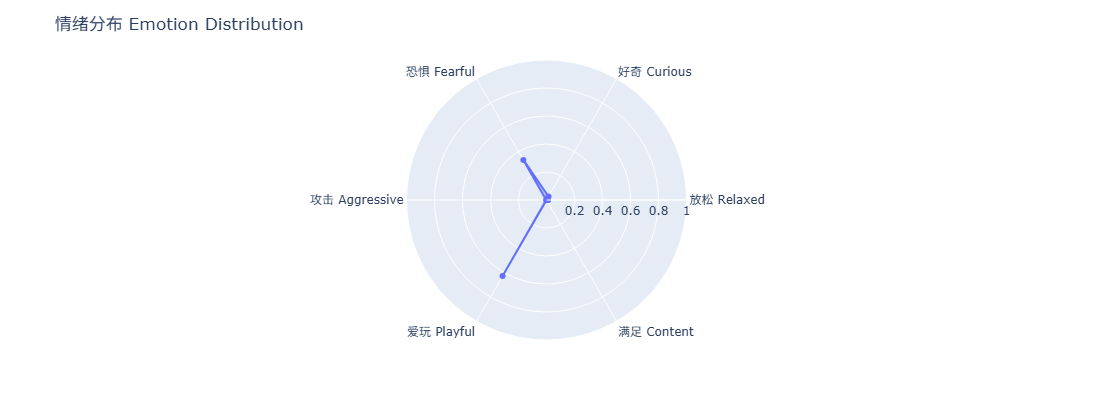

In [17]:
# Test Module C: CLIP emotion classification
from src.emotion import EmotionClassifier

print("Testing CLIP emotion classification...")
classifier = EmotionClassifier()

if detections:
    crop = detections[0]["crop"]
    emotions = classifier.classify(crop, strategy="descriptive")
    
    print("\nEmotion distribution:")
    for emotion, prob in sorted(emotions.items(), key=lambda x: x[1], reverse=True):
        bar = "█" * int(prob * 40)
        print(f"  {emotion:12s}: {prob:.1%} {bar}")
    
    # Radar chart
    from src.utils import make_radar_chart
    fig = make_radar_chart(emotions)
    fig.show()

## ✅ 数据准备完成!

**已完成的工作:**
- [x] 依赖安装
- [x] Oxford-IIIT Pet 猫咪图片下载
- [x] YOLOv8n / CLIP / Qwen3-VL-2B / Qwen3-8B 模型缓存
- [x] 50 张评估集准备
- [x] 标注模板生成

**下一步:**
- 运行 `02_lora_training.ipynb` 进行 LoRA 微调
- 或直接运行 `python app.py` 启动 Gradio Demo (不需要 LoRA 也可以运行)